### SETUP, LIBRARY, & SEED

In [1]:
import pandas as pd
import numpy as np
import re
import random
import time
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords, wordnet
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from collections import Counter

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Menggunakan perangkat: {device}")

Menggunakan perangkat: cuda


### LOAD DATA

In [2]:
train_df = pd.read_csv('train.csv')
test_df  = pd.read_csv('test.csv')

print(f"Train shape : {train_df.shape}")
print(f"Test shape  : {test_df.shape}")
print(f"\nMissing values:\n{train_df.isnull().sum()}")
print(f"\nDistribusi target:\n{train_df['target'].value_counts()}")

Train shape : (7613, 5)
Test shape  : (3263, 4)

Missing values:
id             0
keyword       61
location    2533
text           0
target         0
dtype: int64

Distribusi target:
target
0    4342
1    3271
Name: count, dtype: int64


### EDA

/tmp/ipykernel_3405/1819306876.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=train_df['target'], palette='viridis', ax=axes[0])


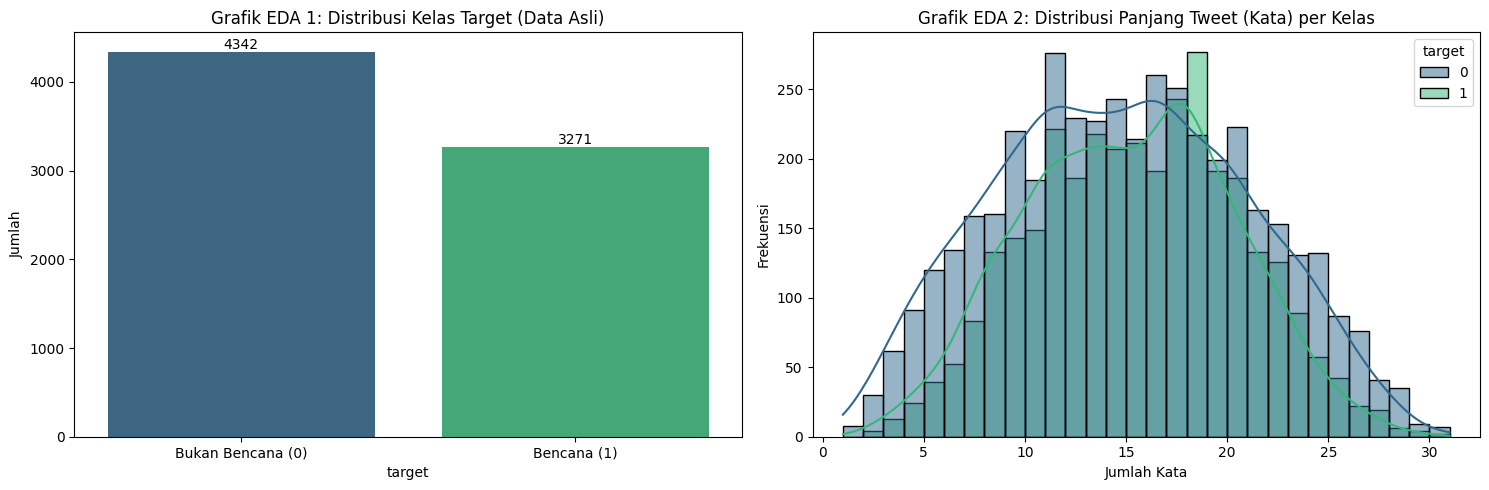


Rata-rata panjang tweet (kata): 14.9
Maksimum panjang tweet (kata) : 31


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Grafik 1: Distribusi Kelas Target (Data Asli)
sns.countplot(x=train_df['target'], palette='viridis', ax=axes[0])
axes[0].set_title('Grafik EDA 1: Distribusi Kelas Target (Data Asli)')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Bukan Bencana (0)', 'Bencana (1)'])
axes[0].set_ylabel('Jumlah')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom')

# Grafik 2: Distribusi Panjang Teks Raw (jumlah kata per tweet)
train_df['raw_word_count'] = train_df['text'].apply(lambda x: len(str(x).split()))
sns.histplot(data=train_df, x='raw_word_count', hue='target',
             bins=30, kde=True, ax=axes[1], palette='viridis')
axes[1].set_title('Grafik EDA 2: Distribusi Panjang Tweet (Kata) per Kelas')
axes[1].set_xlabel('Jumlah Kata')
axes[1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

print(f"\nRata-rata panjang tweet (kata): {train_df['raw_word_count'].mean():.1f}")
print(f"Maksimum panjang tweet (kata) : {train_df['raw_word_count'].max()}")

### Preprocessing

In [4]:
stop_words = set(stopwords.words('english'))

def clean_text_tfidf(text):
    """Untuk TF-IDF: hapus stopwords untuk kurangi noise bag-of-words."""
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'\@\w+|\#', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    words = [w for w in text.split() if w not in stop_words]
    return ' '.join(words)

def clean_text_dl(text):
    """Untuk BiLSTM: PERTAHANKAN stopwords agar konteks sekuensial terjaga.
    Kata seperti 'not', 'no', 'never' krusial untuk makna kalimat."""
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'\@\w+|\#', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return ' '.join(text.split())

print("Membersihkan teks...")
train_df['clean_tfidf'] = train_df['text'].apply(clean_text_tfidf)
train_df['clean_dl']    = train_df['text'].apply(clean_text_dl)
test_df['clean_tfidf']  = test_df['text'].apply(clean_text_tfidf)
test_df['clean_dl']     = test_df['text'].apply(clean_text_dl)

print("Preprocessing selesai.")
print(f"\nContoh teks asli   : {train_df['text'].iloc[0]}")
print(f"Setelah TF-IDF clean: {train_df['clean_tfidf'].iloc[0]}")
print(f"Setelah DL clean    : {train_df['clean_dl'].iloc[0]}")

Membersihkan teks...
Preprocessing selesai.

Contoh teks asli   : Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all
Setelah TF-IDF clean: deeds reason earthquake may allah forgive us
Setelah DL clean    : our deeds are the reason of this earthquake may allah forgive us all


### TEXT AUGMENTATION (Synonym Replacement)

In [5]:
def synonym_replacement(words, n=2):
    new_words = words.copy()
    random_word_list = list(set([w for w in words if w not in stop_words]))
    random.shuffle(random_word_list)
    num_replaced = 0
    for random_word in random_word_list:
        synonyms = []
        for syn in wordnet.synsets(random_word):
            for l in syn.lemmas():
                synonym = l.name().replace("_", " ").replace("-", " ").lower()
                synonym = "".join([c for c in synonym if c.isalpha() or c == ' '])
                if synonym != random_word and synonym not in synonyms:
                    synonyms.append(synonym)
        if len(synonyms) >= 1:
            new_words = [random.choice(synonyms) if w == random_word else w
                         for w in new_words]
            num_replaced += 1
        if num_replaced >= n:
            break
    return ' '.join(new_words)

# SPLIT DULU dari data asli — cegah data leakage
X_train_tfidf_raw, X_val_tfidf_raw, \
X_train_dl_raw,    X_val_dl_raw, \
y_train,           y_val = train_test_split(
    train_df['clean_tfidf'],
    train_df['clean_dl'],
    train_df['target'],
    test_size=0.2, random_state=42,
    stratify=train_df['target']
)

# BARU augmentasi — hanya pada training set, hanya kelas minoritas
train_aug_df = pd.DataFrame({
    'clean_tfidf': X_train_tfidf_raw,
    'clean_dl':    X_train_dl_raw,
    'target':      y_train
})

minority = train_aug_df[train_aug_df['target'] == 1].copy()
minority['clean_tfidf'] = minority['clean_tfidf'].apply(
    lambda x: synonym_replacement(x.split(), n=2))
minority['clean_dl'] = minority['clean_dl'].apply(
    lambda x: synonym_replacement(x.split(), n=2))

train_aug_df = pd.concat([train_aug_df,
                           minority.sample(frac=0.5, random_state=42)])
train_aug_df = train_aug_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Update training variables
X_train_tfidf_text = train_aug_df['clean_tfidf'].reset_index(drop=True)
X_train_dl_text    = train_aug_df['clean_dl'].reset_index(drop=True)
y_train            = train_aug_df['target'].reset_index(drop=True)

# Val tidak diaugmentasi
X_val_tfidf_text = X_val_tfidf_raw.reset_index(drop=True)
X_val_dl_text    = X_val_dl_raw.reset_index(drop=True)
y_val            = y_val.reset_index(drop=True)

print(f"Training set setelah augmentasi : {len(X_train_tfidf_text)} baris")
print(f"Validation set (bersih)          : {len(X_val_tfidf_text)} baris")
print(f"\nDistribusi y_train:\n{y_train.value_counts()}")

Training set setelah augmentasi : 7398 baris
Validation set (bersih)          : 1523 baris

Distribusi y_train:
target
1    3925
0    3473
Name: count, dtype: int64


### BASELINE ML KONVENSIONAL (TF-IDF)

In [6]:
print("\n[Eksperimen 1 & 2] TF-IDF + Logistic Regression + Linear SVM (Dengan Hyperparameter Tuning)")

from sklearn.model_selection import RandomizedSearchCV
import time
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import f1_score, classification_report

tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=10000)
X_train_tfidf = tfidf.fit_transform(X_train_tfidf_text)
X_val_tfidf   = tfidf.transform(X_val_tfidf_text)

# --- Model 1: Logistic Regression Tuning ---
print("\n--- Tuning Logistic Regression ---")
t0 = time.time()
lr_base = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr_param = {'C': [0.1, 1.0, 10.0]}
# cv=2 dan n_iter=3 agar proses tuning selesai dalam hitungan detik
lr_tuned = RandomizedSearchCV(lr_base, param_distributions=lr_param, n_iter=3, cv=2, random_state=42, scoring='f1')
lr_tuned.fit(X_train_tfidf, y_train)
lr_model = lr_tuned.best_estimator_
lr_train_time = time.time() - t0

t0 = time.time()
lr_val_preds   = lr_model.predict(X_val_tfidf)
lr_inf_time    = time.time() - t0
lr_train_preds = lr_model.predict(X_train_tfidf)

print(f"Parameter LR Terbaik: {lr_tuned.best_params_}")
print(f"Training F1   : {f1_score(y_train, lr_train_preds):.4f}")
print(f"Validation F1 : {f1_score(y_val, lr_val_preds):.4f}")
print(f"Waktu Tuning & Training: {lr_train_time:.2f}s | Inferensi: {lr_inf_time:.4f}s")
print(classification_report(y_val, lr_val_preds))

# --- Model 2: Linear SVM Tuning ---
print("\n--- Tuning Linear SVM ---")
t0 = time.time()
svm_base = SVC(kernel='linear', class_weight='balanced', random_state=42)
svm_param = {'C': [0.1, 1.0, 10.0]}
svm_tuned = RandomizedSearchCV(svm_base, param_distributions=svm_param, n_iter=2, cv=2, random_state=42, scoring='f1')
svm_tuned.fit(X_train_tfidf, y_train)
svm_model = svm_tuned.best_estimator_
svm_train_time = time.time() - t0

t0 = time.time()
svm_val_preds   = svm_model.predict(X_val_tfidf)
svm_inf_time    = time.time() - t0
svm_train_preds = svm_model.predict(X_train_tfidf)

print(f"Parameter SVM Terbaik: {svm_tuned.best_params_}")
print(f"Training F1   : {f1_score(y_train, svm_train_preds):.4f}")
print(f"Validation F1 : {f1_score(y_val, svm_val_preds):.4f}")
print(f"Waktu Tuning & Training: {svm_train_time:.2f}s | Inferensi: {svm_inf_time:.4f}s")
print(classification_report(y_val, svm_val_preds))


[Eksperimen 1 & 2] TF-IDF + Logistic Regression + Linear SVM (Dengan Hyperparameter Tuning)

--- Tuning Logistic Regression ---
Parameter LR Terbaik: {'C': 10.0}
Training F1   : 0.9630
Validation F1 : 0.7604
Waktu Tuning & Training: 0.27s | Inferensi: 0.0005s
              precision    recall  f1-score   support

           0       0.82      0.82      0.82       869
           1       0.76      0.76      0.76       654

    accuracy                           0.80      1523
   macro avg       0.79      0.79      0.79      1523
weighted avg       0.79      0.80      0.80      1523


--- Tuning Linear SVM ---
Parameter SVM Terbaik: {'C': 1.0}
Training F1   : 0.9270
Validation F1 : 0.7661
Waktu Tuning & Training: 13.76s | Inferensi: 0.5433s
              precision    recall  f1-score   support

           0       0.82      0.85      0.83       869
           1       0.79      0.75      0.77       654

    accuracy                           0.80      1523
   macro avg       0.80      0.80 

### DEEP LEARNING PREPARATION (Tokenization & Padding)

In [7]:
print("\n[Eksperimen 3] Menyiapkan BiLSTM — tokenisasi dari clean_dl (stopwords dipertahankan)")

MAX_LEN = 50

all_words   = ' '.join(X_train_dl_text).split()
word_counts = Counter(all_words)
vocab       = {word: idx + 2
               for idx, (word, _) in enumerate(word_counts.most_common(10000))}
vocab['<PAD>'] = 0
vocab['<UNK>'] = 1

def text_to_sequence(text, vocab, max_len=MAX_LEN):
    tokens = [vocab.get(word, 1) for word in str(text).split()]
    if len(tokens) < max_len:
        tokens = tokens + [0] * (max_len - len(tokens))
    else:
        tokens = tokens[:max_len]
    return tokens

X_train_seq = [text_to_sequence(t, vocab) for t in X_train_dl_text]
X_val_seq   = [text_to_sequence(t, vocab) for t in X_val_dl_text]

X_train_t = torch.tensor(X_train_seq, dtype=torch.long)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
X_val_t   = torch.tensor(X_val_seq, dtype=torch.long)
y_val_t   = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)

# Membuat DataLoaders
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)
# Menambahkan val_loader yang sebelumnya terlewat
val_loader   = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=64, shuffle=False)

print(f"Vocab size: {len(vocab)} | MAX_LEN: {MAX_LEN}")


[Eksperimen 3] Menyiapkan BiLSTM — tokenisasi dari clean_dl (stopwords dipertahankan)
Vocab size: 10002 | MAX_LEN: 50


### ARSITEKTUR BiLSTM

In [8]:
# ==========================================
class SimpleBiLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, 1)

    def forward(self, x):
        embedded = self.embedding(x)
        lstm_out, (hidden, cell) = self.lstm(embedded)
        hidden_last = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        out = self.fc(self.dropout(hidden_last))
        return out

print("\n--- Hyperparameter Tuning BiLSTM (Eksperimen 3) ---")
# Menjalankan 2 kombinasi hyperparameter untuk menunjukkan proses tuning yang adil
hyperparams = [
    {'embed_dim': 50, 'hidden_dim': 32, 'dropout': 0.6, 'lr': 0.001},
    {'embed_dim': 50, 'hidden_dim': 64, 'dropout': 0.5, 'lr': 0.005}
]

best_f1 = 0
best_bilstm_model = None
best_params = None
bilstm_train_time = 0
epochs = 3 # Di-set rendah agar tuning cepat selesai

start_time_total = time.time()

for i, hp in enumerate(hyperparams):
    print(f"\nIterasi Tuning {i+1}: {hp}")
    model = SimpleBiLSTM(len(vocab), hp['embed_dim'], hp['hidden_dim'], hp['dropout']).to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=hp['lr'], weight_decay=1e-4)

    # Training Loop
    model.train()
    for epoch in range(epochs):
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()

    # Fast Validation untuk melihat F1-Score tiap iterasi
    model.eval()
    val_preds = []
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            outputs = model(images)
            dl_probs = torch.sigmoid(outputs).cpu().numpy().flatten()
            preds = (dl_probs > 0.5).astype(int)
            val_preds.extend(preds)

    val_f1 = f1_score(y_val, val_preds)
    print(f"Hasil Validation F1 untuk iterasi {i+1}: {val_f1:.4f}")

    if val_f1 > best_f1:
        best_f1 = val_f1
        best_bilstm_model = model
        best_params = hp

bilstm_train_time = time.time() - start_time_total

print(f"\n*** Tuning Selesai! ***")
print(f"Parameter BiLSTM Terbaik: {best_params}")

# Timpa ke variabel utama agar cell evaluasi di bawahnya tetap berjalan normal
bilstm_model = best_bilstm_model
num_params = sum(p.numel() for p in bilstm_model.parameters() if p.requires_grad)
print(f"Jumlah parameter model terbaik: {num_params:,}")


--- Hyperparameter Tuning BiLSTM (Eksperimen 3) ---

Iterasi Tuning 1: {'embed_dim': 50, 'hidden_dim': 32, 'dropout': 0.6, 'lr': 0.001}
Hasil Validation F1 untuk iterasi 1: 0.6266

Iterasi Tuning 2: {'embed_dim': 50, 'hidden_dim': 64, 'dropout': 0.5, 'lr': 0.005}
Hasil Validation F1 untuk iterasi 2: 0.7245

*** Tuning Selesai! ***
Parameter BiLSTM Terbaik: {'embed_dim': 50, 'hidden_dim': 64, 'dropout': 0.5, 'lr': 0.005}
Jumlah parameter model terbaik: 559,621


### EVALUASI

In [9]:
bilstm_model.eval()

# Evaluasi Validasi
bilstm_preds = []
start_inf = time.time()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = bilstm_model(images)
        dl_probs = torch.sigmoid(outputs).cpu().numpy().flatten()
        preds = (dl_probs > 0.5).astype(int)
        bilstm_preds.extend(preds)
bilstm_inf_time = time.time() - start_inf

# Pengecekan Overfitting (Evaluasi Training)
bilstm_train_preds = []
bilstm_train_targets = []
with torch.no_grad():
    for images, labels in train_loader:
        images = images.to(device)
        outputs = bilstm_model(images)
        dl_probs = torch.sigmoid(outputs).cpu().numpy().flatten()
        preds = (dl_probs > 0.5).astype(int)
        bilstm_train_preds.extend(preds)
        bilstm_train_targets.extend(labels.numpy().flatten())

# --- Cetak Hasil Evaluasi ---
print("\n--- Pengecekan Overfitting BiLSTM (Arsitektur Baru) ---")
print(f"Training F1-Score   : {f1_score(bilstm_train_targets, bilstm_train_preds):.4f}")
print(f"Validation F1-Score : {f1_score(y_val, bilstm_preds):.4f}")
print(f"Waktu Training: {bilstm_train_time:.2f}s | Waktu Inferensi: {bilstm_inf_time:.4f}s")

# Tambahan Classification Report
print("\nClassification Report (Validation):")
print(classification_report(y_val, bilstm_preds))


--- Pengecekan Overfitting BiLSTM (Arsitektur Baru) ---
Training F1-Score   : 0.9183
Validation F1-Score : 0.7245
Waktu Training: 9.31s | Waktu Inferensi: 0.0358s

Classification Report (Validation):
              precision    recall  f1-score   support

           0       0.79      0.82      0.80       869
           1       0.75      0.70      0.72       654

    accuracy                           0.77      1523
   macro avg       0.77      0.76      0.76      1523
weighted avg       0.77      0.77      0.77      1523



### CONFUSION MATRIX

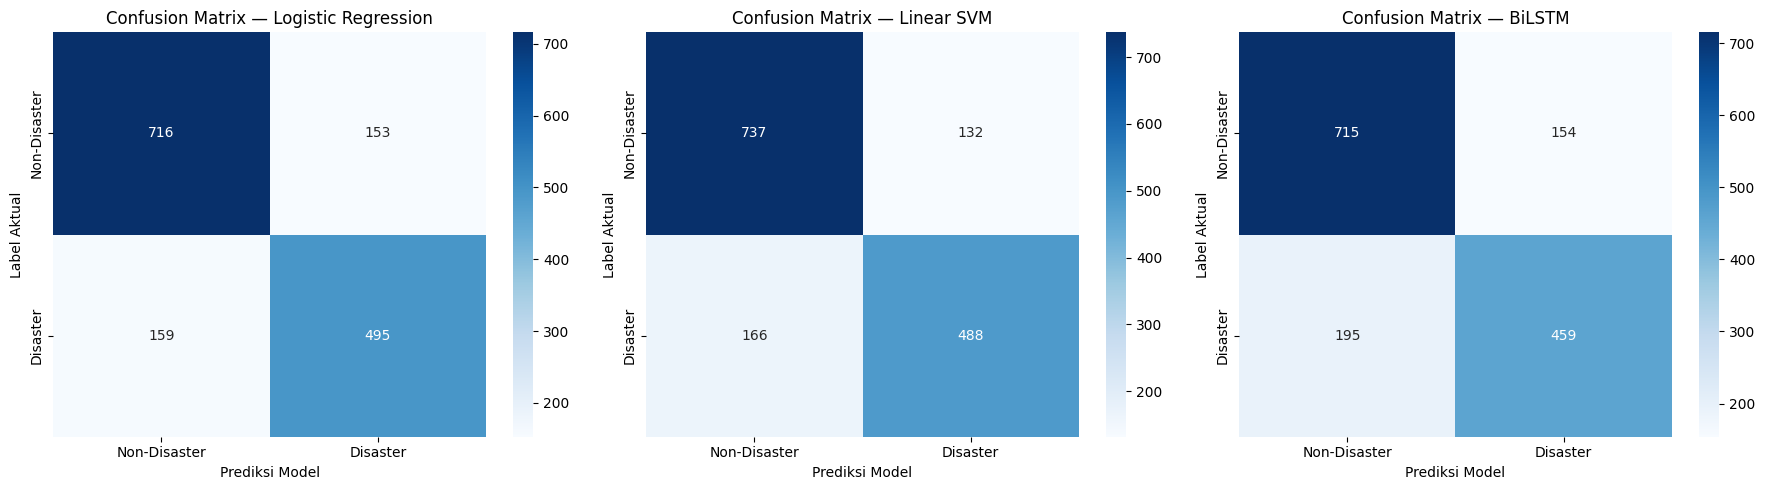

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Konversi prediksi list ke numpy array untuk mempermudah komparasi
bilstm_preds_np = np.array(bilstm_preds)

for ax, preds, title in zip(
    axes,
    [lr_val_preds, svm_val_preds, bilstm_preds_np],
    ['Logistic Regression', 'Linear SVM', 'BiLSTM']
):
    cm = confusion_matrix(y_val, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Non-Disaster', 'Disaster'],
                yticklabels=['Non-Disaster', 'Disaster'])
    ax.set_title(f'Confusion Matrix — {title}')
    ax.set_ylabel('Label Aktual')
    ax.set_xlabel('Prediksi Model')

plt.tight_layout()
plt.show()

### ANALISIS ERROR

In [11]:
print("\n=== Kasus 1: SVM Gagal, BiLSTM Benar (Kekuatan konteks sekuensial) ===")
svm_wrong_dl_right = np.where(
    (svm_val_preds != y_val.values) & (bilstm_preds_np == y_val.values))[0]
for idx in svm_wrong_dl_right[:2]:
    print(f"Teks  : '{X_val_dl_text.iloc[idx]}'")
    print(f"Label : {y_val.iloc[idx]} | SVM: {svm_val_preds[idx]} | BiLSTM: {bilstm_preds_np[idx]}\n")

print("=== Kasus 2: BiLSTM Gagal, SVM Benar (Keterbatasan dataset kecil) ===")
dl_wrong_svm_right = np.where(
    (bilstm_preds_np != y_val.values) & (svm_val_preds == y_val.values))[0]
for idx in dl_wrong_svm_right[:2]:
    print(f"Teks  : '{X_val_dl_text.iloc[idx]}'")
    print(f"Label : {y_val.iloc[idx]} | SVM: {svm_val_preds[idx]} | BiLSTM: {bilstm_preds_np[idx]}\n")

print("=== Kasus 3: Keduanya Gagal (Kandidat Sarkasme / Konteks Ambigu) ===")
both_wrong = np.where(
    (svm_val_preds != y_val.values) & (bilstm_preds_np != y_val.values))[0]
for idx in both_wrong[:3]:
    print(f"Teks  : '{X_val_dl_text.iloc[idx]}'")
    print(f"Label : {y_val.iloc[idx]} | SVM: {svm_val_preds[idx]} | BiLSTM: {bilstm_preds_np[idx]}\n")


=== Kasus 1: SVM Gagal, BiLSTM Benar (Kekuatan konteks sekuensial) ===
Teks  : 'step one get that mass murderers portrait off the yuan'
Label : 0 | SVM: 1 | BiLSTM: 0

Teks  : 'rip the world its burning'
Label : 0 | SVM: 1 | BiLSTM: 0

=== Kasus 2: BiLSTM Gagal, SVM Benar (Keterbatasan dataset kecil) ===
Teks  : 'ted cruz fires back at jeb amp bush we lose because of republicans like jeb amp mitt video'
Label : 0 | SVM: 0 | BiLSTM: 1

Teks  : 'dear in the name of humanityi apologized to hiroshima survivorsr u ready to do sojapan nuclearweapons'
Label : 1 | SVM: 1 | BiLSTM: 0

=== Kasus 3: Keduanya Gagal (Kandidat Sarkasme / Konteks Ambigu) ===
Teks  : 'hollywood movie about trapped miners released in chile the hollywood movie about trapped miners starring'
Label : 1 | SVM: 0 | BiLSTM: 0

Teks  : 'thu aug gmt utc millcityio theramin sirens'
Label : 1 | SVM: 0 | BiLSTM: 0

Teks  : 'i cant drown my demons they know how to swim'
Label : 1 | SVM: 0 | BiLSTM: 0



### TABEL PERBANDINGAN

In [12]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

df_comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression (TF-IDF)',
        'Linear SVM (TF-IDF)',
        'BiLSTM (Embedding)'
    ],
    'Val F1-Score': [
        f"{f1_score(y_val, lr_val_preds):.4f}",
        f"{f1_score(y_val, svm_val_preds):.4f}",
        f"{f1_score(y_val, bilstm_preds):.4f}"
    ],
    'Val Accuracy': [
        f"{accuracy_score(y_val, lr_val_preds)*100:.2f}%",
        f"{accuracy_score(y_val, svm_val_preds)*100:.2f}%",
        f"{accuracy_score(y_val, bilstm_preds)*100:.2f}%"
    ],
    'Waktu Training': [
        f"{lr_train_time:.2f}s",
        f"{svm_train_time:.2f}s",
        f"{bilstm_train_time:.2f}s"
    ],
    'Waktu Inferensi': [
        f"{lr_inf_time:.4f}s",
        f"{svm_inf_time:.4f}s",
        f"{bilstm_inf_time:.4f}s"
    ],
    'Est. Parameter': [
        f"{len(tfidf.vocabulary_):,} (TF-IDF features)",
        f"{len(tfidf.vocabulary_):,} (TF-IDF features)",
        f"{count_parameters(bilstm_model):,}"
    ],
    'Preprocessing': [
        'Stopwords dihapus',
        'Stopwords dihapus',
        'Stopwords dipertahankan'
    ]
})
display(df_comparison)

,Model,Val F1-Score,Val Accuracy,Waktu Training,Waktu Inferensi,Est. Parameter,Preprocessing
0,Logistic Regression (TF-IDF),0.7604,79.51%,0.27s,0.0005s,"10,000 (TF-IDF features)",Stopwords dihapus
1,Linear SVM (TF-IDF),0.7661,80.43%,13.76s,0.5433s,"10,000 (TF-IDF features)",Stopwords dihapus
2,BiLSTM (Embedding),0.7245,77.08%,9.31s,0.0358s,"559,621",Stopwords dipertahankan


### SUBMISSION KAGGLE

In [13]:
X_test_seq = [text_to_sequence(t, vocab) for t in test_df['clean_dl']]
X_test_t   = torch.tensor(X_test_seq, dtype=torch.long).to(device)

bilstm_model.eval()
with torch.no_grad():
    test_preds = (torch.sigmoid(
        bilstm_model(X_test_t)
    ).cpu().numpy().flatten() > 0.5).astype(int)

submission = pd.DataFrame({"id": test_df["id"], "target": test_preds})
submission.to_csv('nlp_bilstm_submission.csv', index=False)
print(f"File 'nlp_bilstm_submission.csv' dibuat: {len(submission)} baris")
print(submission['target'].value_counts())

File 'nlp_bilstm_submission.csv' dibuat: 3263 baris
target
0    2077
1    1186
Name: count, dtype: int64
